In [10]:
import geopandas as gpd
import pandas as pd
import math
import os

In [11]:
data_dir = os.path.join(os.getcwd(), "data")
clusters_filename = os.path.join(data_dir, "roads_areas_clustered.gpkg")

clusters = gpd.read_file(clusters_filename)

In [12]:
clusters["area"] = clusters.geometry.area

In [13]:
dispersal_distance = {
    1: 2000,
    1.1: 1500,
    1.2: 3000,

    2: 1000,
    2.1: 800,
    2.3: 700,
    2.4: 500,

    3: 300,
    3.1: 200,
    3.2: 400,
    3.3: 300,
    3.4: 500,
    3.5: 400,

    4: 600,
    4.0: 300,
    4.1: 400,
    4.2: 700,
    4.3: 500,
    4.4: 300,
    4.5: 800,
    4.6: 700,
    4.7: 600,

    5: 900,
    5.2: 700,
    5.3: 1000,
    5.4: 600,

    6: 1500,
    6.1: 1200,
    6.2: 1500,
    6.3: 1800,
    6.4: 1700,
    6.5: 1600,
    6.6: 1500,
    6.7: 1000,

    7: 400,
    7.1: 400,

    8: 700,
    8.1: 900,
    8.2: 600,

    9: 150,
    9.2: 100,
    9.3: 50,
    9.4: 50
}

In [14]:
for cluster_id, cluster in clusters.groupby(["cluster_v2", "TypoCH_v2"]):
    PC = 0.0

    alpha = dispersal_distance.get(float(cluster.iloc[0]["TypoCH_v2"]))

    if alpha is None:
        print(f"Warning: no dispersal distance found for TypoCH_v2={cluster.iloc[0]['TypoCH_v2']}. Skipping cluster {cluster_id}.")
        alpha = 1
    
    total_area = cluster["area"].sum()
    
    for i in range(len(cluster)):
        
        a_i = cluster.iloc[i]["area"]
        
        for j in range(len(cluster)):

            a_j = cluster.iloc[j]["area"]
            dist_ij = cluster.iloc[i].geometry.centroid.distance(cluster.iloc[j].geometry.centroid)

            p_ij = math.pow(math.e, -dist_ij / alpha)

            PC += a_i * a_j * p_ij
    
    PC /= math.pow(total_area, 2)
    
    clusters.loc[cluster.index, "PC"] = PC

In [15]:
clusters["PC"].describe()

count    4433.000000
mean        0.864991
std         0.107418
min         0.415161
25%         0.811899
50%         0.883306
75%         0.950055
max         0.999996
Name: PC, dtype: float64

<Axes: >

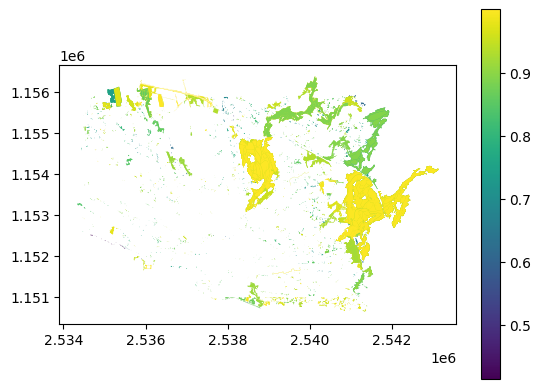

In [16]:
clusters.plot(column="PC", legend=True)